In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
df = pd.read_csv('data/results.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)


In [107]:
#Calcular resultado de cada partido
def calculate_result(row):
    if row['home_score'] > row['away_score']:
        return 1
    elif row['home_score'] < row['away_score']:
        return 2
    else:
        return 0
    
df['result'] = df.apply(calculate_result, axis=1)
df

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1
...,...,...,...,...,...,...,...,...,...,...
49282,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True,0
49283,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True,0
49284,2026-06-27,Algeria,Austria,NaN,NaN,FIFA World Cup,Kansas City,United States,True,0
49285,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True,0


In [108]:
df=df[df['neutral'] == False]
df

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1
...,...,...,...,...,...,...,...,...,...,...
49242,2026-06-18,Canada,Qatar,NaN,NaN,FIFA World Cup,Vancouver,Canada,False,0
49243,2026-06-19,United States,Australia,NaN,NaN,FIFA World Cup,Seattle,United States,False,0
49267,2026-06-24,Mexico,Czech Republic,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False,0
49268,2026-06-24,Canada,Switzerland,NaN,NaN,FIFA World Cup,Vancouver,Canada,False,0


In [109]:
# Asignamos un peso del 1 al 4 según la relevancia competitiva
def tournament_weight(tournament):
    torneo = str(tournament)
    if 'FIFA World Cup' in torneo and 'FIFA World Cup qualification' not in torneo:
        return 4  # El Mundial 
    elif 'Copa América' in torneo or 'UEFA Euro' in torneo and 'qualification' not in torneo:
        return 3  # Torneos continentales
    elif 'FIFA World Cup qualification' in torneo or 'nations league' in torneo or 'confederations' in torneo:
        return 2  # Clasificatorios y torneos oficiales menores
    elif 'Friendly' in torneo:
        return 1  # Amistosos
    else:
        return 1.5 # Otros torneos menores (Copas de invitación, etc.)

df['tournament_weight'] = df['tournament'].apply(tournament_weight)
df

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,tournament_weight
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False,0,1.0
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False,1,1.0
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False,1,1.0
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False,0,1.0
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...
49242,2026-06-18,Canada,Qatar,NaN,NaN,FIFA World Cup,Vancouver,Canada,False,0,4.0
49243,2026-06-19,United States,Australia,NaN,NaN,FIFA World Cup,Seattle,United States,False,0,4.0
49267,2026-06-24,Mexico,Czech Republic,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False,0,4.0
49268,2026-06-24,Canada,Switzerland,NaN,NaN,FIFA World Cup,Vancouver,Canada,False,0,4.0


In [110]:
# Extraemos los datos del equipo LOCAL
df_local = df[['date', 'home_team', 'home_score', 'away_score', 'result']].rename(
    columns={'home_team': 'team', 'home_score': 'goals_for', 'away_score': 'goals_against'}
)
df_local['points'] = df_local['result'].map({1: 3, 0: 1, 2: 0})

# Extraemos los datos del equipo VISITANTE
df_away = df[['date', 'away_team', 'away_score', 'home_score', 'result']].rename(
    columns={'away_team': 'team', 'away_score': 'goals_for', 'home_score': 'goals_against'}
)
df_away['points'] = df_away['result'].map({1: 0, 0: 1, 2: 3})

df_time = pd.concat([df_local, df_away]).sort_values('date')

df_time

,date,team,goals_for,goals_against,result,points
0,1872-11-30,Scotland,0.0,0.0,0,1
0,1872-11-30,England,0.0,0.0,0,1
1,1873-03-08,Scotland,2.0,4.0,1,0
1,1873-03-08,England,4.0,2.0,1,3
2,1874-03-07,Scotland,2.0,1.0,1,3
...,...,...,...,...,...,...
49267,2026-06-24,Mexico,NaN,NaN,0,1
49268,2026-06-24,Switzerland,NaN,NaN,0,1
49267,2026-06-24,Czech Republic,NaN,NaN,0,1
49269,2026-06-25,United States,NaN,NaN,0,1


In [111]:
# calculamos medias moviles de goles y puntos para cada equipo
def calculate_moving_averages(df, window=30):
    df = df.sort_values('date')
    group = df.groupby('team')
    df['avg_goals_for'] = group['goals_for'].shift(1).rolling(window=window, min_periods=1).mean()
    df['avg_goals_against'] = group['goals_against'].shift(1).rolling(window=window, min_periods=1).mean()
    df['avg_points'] = group['points'].shift(1).rolling(window=window, min_periods=1).mean()
    return df
df_time = calculate_moving_averages(df_time)
df_clean = df_time[['date', 'team', 'avg_goals_for', 'avg_goals_against', 'avg_points']].drop_duplicates(subset=['date', 'team'])


In [112]:
#volvemos a la estructura original con un row por partido

df = df.merge(df_clean, left_on=['date', 'home_team'], right_on=['date', 'team'], how='left')
df = df.rename(columns={
    'avg_goals_for': 'avg_goals_for_local', 
    'avg_goals_against': 'avg_goals_against_local',
    'avg_points': 'avg_points_local'
}).drop(columns=['team'])

df = df.merge(df_clean, left_on=['date', 'away_team'], right_on=['date', 'team'], how='left')
df = df.rename(columns={
    'avg_goals_for': 'avg_goals_for_away', 
    'avg_goals_against': 'avg_goals_against_away',
    'avg_points': 'avg_points_away'
}).drop(columns=['team'])


In [124]:
# calculamos diferencias entre local y visitante
df['diff_avg_goals_for'] = df['avg_goals_for_local'] - df['avg_goals_for_away']
df['diff_avg_goals_against'] = df['avg_goals_against_local'] - df['avg_goals_against_away']
df['diff_avg_points'] = df['avg_points_local'] - df['avg_points_away']


# Aplicamos restricción para dejar fuera los partidos futuros del Mundial 2026 en el set de entreno
df_final = df_final[df_final['date'] < '2026-05-01']

# Eliminamos nulos en las columnas esenciales de entrenamiento
columnas_control_nulos = ['result', 'avg_goals_for_local', 'avg_points_local']
df_final = df_final.dropna(subset=columnas_control_nulos)

#Termina el preprocesamiento de los partidos
df_final

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,...,avg_goals_for_local,avg_goals_against_local,avg_points_local,avg_goals_for_away,avg_goals_against_away,avg_points_away,diff_avg_goals_for,diff_avg_goals_against,diff_avg_points,result_text
13165,1990-01-17,Greece,Belgium,2.0,0.0,Friendly,Athens,Greece,False,1,...,1.033333,0.800000,1.600000,1.000000,0.900000,1.500000,0.033333,-0.100000,0.100000,1 (Home Win)
13166,1990-01-20,Eswatini,Botswana,3.0,1.0,Friendly,Lobamba,Swaziland,False,1,...,1.033333,0.800000,1.600000,1.100000,0.766667,1.700000,-0.066667,0.033333,-0.100000,1 (Home Win)
13167,1990-01-21,Eswatini,Tanzania,0.0,1.0,Friendly,Lobamba,Swaziland,False,2,...,1.200000,0.800000,1.733333,1.133333,0.800000,1.666667,0.066667,0.000000,0.066667,2 (Away Win)
13168,1990-01-21,Kuwait,France,0.0,1.0,Friendly,Kuwait City,Kuwait,False,2,...,1.100000,0.766667,1.666667,1.133333,0.766667,1.700000,-0.033333,0.000000,-0.033333,2 (Away Win)
13169,1990-01-25,Nigeria,Ivory Coast,2.0,0.0,Friendly,Bauchi,Nigeria,False,1,...,1.233333,0.633333,1.733333,1.166667,0.633333,1.733333,0.066667,0.000000,0.000000,1 (Home Win)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36234,2026-03-31,Norway,Switzerland,0.0,0.0,Friendly,Oslo,Norway,False,0,...,1.966667,1.600000,1.566667,1.966667,1.900000,1.466667,0.000000,-0.300000,0.100000,0 (Draw)
36235,2026-03-31,Hungary,Greece,0.0,0.0,Friendly,Budapest,Hungary,False,0,...,2.000000,1.566667,1.666667,1.900000,2.066667,1.333333,0.100000,-0.500000,0.333333,0 (Draw)
36236,2026-03-31,Botswana,Malawi,1.0,0.0,Mukuru 4 Nations,Francistown,Botswana,False,1,...,2.066667,1.766667,1.566667,2.066667,1.833333,1.566667,0.000000,-0.066667,0.000000,1 (Home Win)
36237,2026-03-31,Montenegro,Slovenia,2.0,3.0,Friendly,Podgorica,Montenegro,False,2,...,2.033333,1.500000,1.600000,1.833333,1.500000,1.500000,0.200000,0.000000,0.100000,2 (Away Win)


In [117]:
# estudiamos la correlacion

resultado_map = {1: "1 (Home Win)", 0: "0 (Draw)", 2: "2 (Away Win)"}
df_final["result_text"] = df_final["result"].map(resultado_map)
features = [
    "diff_avg_goals_for",
    "diff_avg_goals_against",
    "diff_avg_points",
    "tournament_weight",
]
df_final = df_final.dropna(subset=features)


mi_scores = mutual_info_classif(df_final[features], df_final["result"], random_state=99)

mi_df = (
    pd.DataFrame({"Variable": features, "Importance (MI)": mi_scores})
    .sort_values(by="Importance (MI)", ascending=False)
    .reset_index(drop=True)
)

print("--- IMPORTANCE OF THE VARIABLES (MUTUAL INFORMATION) ---")
print(mi_df)
print("\n" + "=" * 50 + "\n")

#tabla medias por resultado

avg_by_result = df_final.groupby("result_text")[features].mean()
print("--- AVERAGE VALUES OF THE VARIABLES BY RESULT ---")
print(avg_by_result)
print("\n" + "=" * 50 + "\n")

--- IMPORTANCE OF THE VARIABLES (MUTUAL INFORMATION) ---
                 Variable  Importance (MI)
0      diff_avg_goals_for         0.005176
1         diff_avg_points         0.002868
2  diff_avg_goals_against         0.000106
3       tournament_weight         0.000000


--- AVERAGE VALUES OF THE VARIABLES BY RESULT ---
              diff_avg_goals_for  diff_avg_goals_against  diff_avg_points  \
result_text                                                                 
0 (Draw)               -0.006371                0.002626         0.002107   
1 (Home Win)            0.003778               -0.004998         0.008275   
2 (Away Win)           -0.013172                0.013165        -0.006759   

              tournament_weight  
result_text                      
0 (Draw)               1.427649  
1 (Home Win)           1.475043  
2 (Away Win)           1.487660  




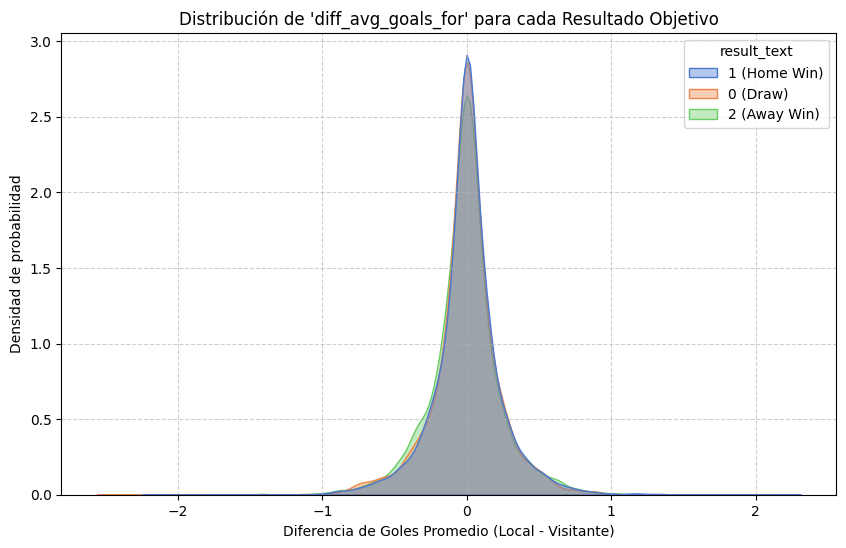

In [126]:
plt.figure(figsize=(10, 6))

# Analizamos la variable que debería ser la más potente: diff_avg_points
orden_clases = [
    "1 (Home Win)",
    "0 (Draw)",
    "2 (Away Win)",
]  # Aseguramos el orden en el gráfico
sns.kdeplot(
    data=df_final,
    x="diff_avg_goals_for",
    hue="result_text",
    hue_order=orden_clases,
    fill=True,
    common_norm=False,
    palette="muted",
    alpha=0.4,
)

plt.title("Distribución de 'diff_avg_goals_for' para cada Resultado Objetivo")
plt.xlabel("Diferencia de Goles Promedio (Local - Visitante)")
plt.ylabel("Densidad de probabilidad")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [134]:
# unificamos los archivos de ranking en uno solo para facilitar el merge_asof posterior
ranking_files = [
    'data/fifa_ranking-2023-07-20.csv',  # Cambia estos nombres por tus rutas reales
    'data/fifa_ranking-2024-04-04.csv',
    'data/fifa_ranking-2024-06-20.csv'
]

# Leemos y concatenamos los tres archivos en uno solo
df_ranking = pd.concat([pd.read_csv(f) for f in ranking_files], ignore_index=True)
# Convertimos la fecha a formato datetime
df_ranking['rank_date'] = pd.to_datetime(df_ranking['rank_date'])

# Nos quedamos solo con las columnas que aportan valor al modelo
df_ranking_clean = df_ranking[['rank_date', 'country_full', 'total_points', 'rank']].copy()


,rank_date,country_full,total_points,rank
0,1992-12-31,Germany,57.00,1.0
64860,1992-12-31,Korea DPR,16.00,77.0
64861,1992-12-31,Peru,16.00,78.0
64862,1992-12-31,Sierra Leone,16.00,79.0
64863,1992-12-31,Tanzania,15.00,80.0
...,...,...,...,...
199352,2024-06-20,France,1837.47,2.0
199353,2024-06-20,Madagascar,1203.66,104.0
199354,2024-06-20,Morocco,1669.44,12.0
199356,2024-06-20,Poland,1541.49,26.0


In [135]:
# Filtramos los partidos para empezar a partir del 1 de enero de 1993
df_final = df_final[df_final['date'] >= '1992-01-31'].copy()
df_final = df_final.sort_values('date')
df_final

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,result,...,avg_goals_for_local,avg_goals_against_local,avg_points_local,avg_goals_for_away,avg_goals_against_away,avg_points_away,diff_avg_goals_for,diff_avg_goals_against,diff_avg_points,result_text
14340,1993-01-02,Gabon,Burkina Faso,1.0,1.0,Friendly,Libreville,Gabon,False,0,...,1.233333,1.733333,1.233333,1.266667,1.700000,1.300000,-0.033333,0.033333,-0.066667,0 (Draw)
14341,1993-01-02,Kuwait,Lebanon,2.0,0.0,Friendly,Kuwait City,Kuwait,False,1,...,1.200000,1.733333,1.166667,1.166667,1.833333,1.200000,0.033333,-0.100000,-0.033333,1 (Home Win)
14342,1993-01-03,Gabon,Ghana,2.0,3.0,Friendly,Libreville,Gabon,False,2,...,1.166667,1.800000,1.233333,1.233333,1.800000,1.300000,-0.066667,0.000000,-0.066667,2 (Away Win)
14343,1993-01-08,Uganda,Tanzania,3.0,1.0,Friendly,Kampala,Uganda,False,1,...,1.233333,1.766667,1.300000,1.300000,1.633333,1.400000,-0.066667,0.133333,-0.100000,1 (Home Win)
14344,1993-01-10,Angola,Zimbabwe,1.0,1.0,FIFA World Cup qualification,Luanda,Angola,False,0,...,1.433333,1.600000,1.400000,1.433333,1.533333,1.566667,0.000000,0.066667,-0.166667,0 (Draw)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36213,2026-03-31,Spain,Egypt,0.0,0.0,Friendly,Barcelona,Spain,False,0,...,1.766667,2.066667,1.333333,1.500000,1.133333,1.633333,0.266667,0.933333,-0.300000,0 (Draw)
36223,2026-03-31,Bosnia and Herzegovina,Italy,1.0,1.0,FIFA World Cup qualification,Zenica,Bosnia and Herzegovina,False,0,...,1.433333,1.300000,1.533333,1.766667,1.033333,1.833333,-0.333333,0.266667,-0.300000,0 (Draw)
36222,2026-03-31,Wales,Northern Ireland,1.0,1.0,Friendly,Cardiff,Wales,False,0,...,1.400000,1.266667,1.533333,1.766667,1.066667,1.833333,-0.366667,0.200000,-0.300000,0 (Draw)
36225,2026-03-31,Kosovo,Turkey,0.0,1.0,FIFA World Cup qualification,Pristina,Kosovo,False,2,...,1.433333,1.333333,1.500000,1.733333,1.100000,1.733333,-0.300000,0.233333,-0.233333,2 (Away Win)


In [ ]:
# Cruce para el Equipo Local
df_ranking_clean_sorted = df_ranking_clean.sort_values('rank_date')
df_unified = pd.merge_asof(
    df_final, 
    df_ranking_clean_sorted[['rank_date', 'country_full', 'total_points', 'rank']], 
    left_on='date', 
    right_on='rank_date', 
    left_by='home_team', 
    right_by='country_full', 
    direction='backward'
)

df_uni

ValueError: right keys must be sorted